In [1]:
"""
my RF: regression example by Random Forest
"""

'\nmy RF: regression example by Random Forest\n'

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.datasets import fetch_california_housing
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn import metrics
from scipy.stats import mode as moda


In [3]:
# Prepare and show dataset(s)
# X, y = load_boston(return_X_y=True)
X, y = load_diabetes(return_X_y=True)
Xtr, Xts, ytr, yts = train_test_split(X, y, test_size=0.3)

In [4]:
predictor = DecisionTreeRegressor
# predictor = LinearRegression
criterion = 'squared_error'
max_depth = 4  # None for max
report = metrics.mean_squared_error

In [5]:
#%% Create a single predictor (for reference)
dt = predictor(criterion=criterion,
               max_depth=max_depth, random_state=0)
# Train / prediction of single predictor
dt.fit(Xtr, ytr)
yp = dt.predict(Xts)
print('Res tree:', report(yts, yp))

Res tree: 3983.3277712008125


In [6]:
#%% Train bagging ensemble
T = 200
# bag  variable to store the trees (for ex., a list)
n_samples = np.arange(len(ytr))
bag = []
y_oob = np.ones((T, len(ytr))) * np.nan
# loop for the number of trees
for t in range(T):
    # xx, yy = resample(Xtr, ytr, replace=True)
    idx = resample(n_samples, replace=True)
    pred = predictor(criterion=criterion,
                     max_depth=max_depth,
                     max_features=0.5)
    pred.fit(Xtr[idx], ytr[idx])
    bag.append(pred)

    oob = np.setdiff1d(n_samples, idx)
    y_oob[t, oob] = pred.predict(Xtr[oob])


In [7]:
yf_oob = np.nanmean(y_oob, axis=0)

In [8]:
# Test
# Obtain T predictions
yb = np.zeros((T, len(yts)))
for n, t in enumerate(bag):
    yb[n,:] = t.predict(Xts)

In [9]:
# For classification, majority vote (or mode => scipy stats.mode)
yf = np.mean(yb, axis=0)

In [10]:

# Evaluate and compare results
print('Res RF:  ', report(yts, yf))

print('Res OOB: ', report(ytr, yf_oob))

Res RF:   3143.9926501337477
Res OOB:  3329.8881639945043


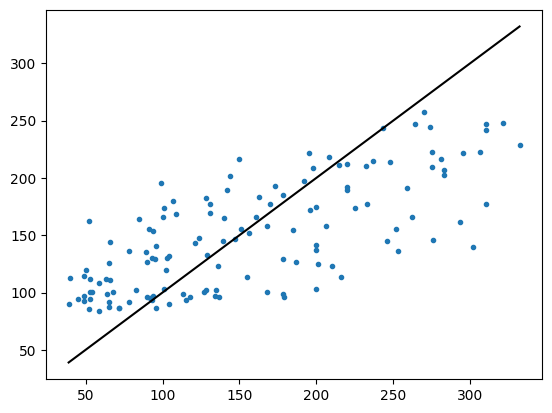

In [11]:
plt.plot(yts,yf,'.')
plt.plot([np.min(yts),np.max(yts)],[np.min(yts),np.max(yts)],'-k')

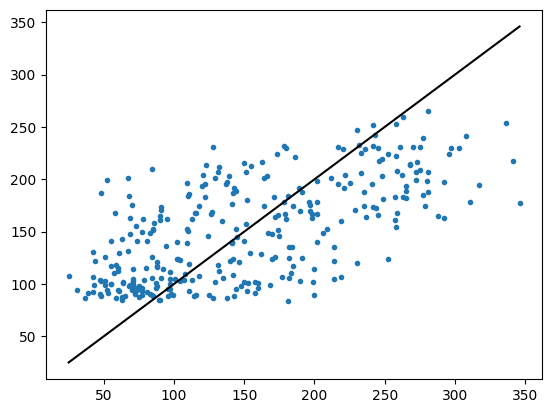

In [12]:
plt.plot(ytr,yf_oob,'.')
plt.plot([np.min(ytr),np.max(ytr)],[np.min(ytr),np.max(ytr)],'-k')